In [295]:
########################################
#getting system arguments
import sys
def GetArg_dataName(default="Variables"):
    """
    Safely retrieve dataName from sys.argv.
    #Run One: python Tracked_Profiles.py Variables
    #Run Two: python Tracked_Profiles.py UpdraftArea
    ##Run Two: python Tracked_Profiles.py Entrainment
    #Run Three: python Tracked_Profiles.py PROCESSED_Entrainment (also can add _DivideMassFlux)
    # Run Four: python Tracked_Profiles.py Budgets
    """
    # If run inside Jupyter, sys.argv will include ipykernel arguments
    if any("ipykernel_launcher" in arg for arg in sys.argv):
        print(f"Using default dataName: {default}")
        return default

    # If a user-specified argument exists, use it
    if len(sys.argv) > 1:
        out=sys.argv[1]
        print(f"Using argument dataName: {out}")
        return out

    return default

dataName = GetArg_dataName()

Using default dataName: Variables


In [296]:
#testing
dataName='Variables'
# dataName='UpdraftArea'
# dataName='Budgets'
# dataName='PROCESSED_Entrainment'
# dataName='PROCESSED_Entrainment_DivideMassFlux'

In [297]:
#Setting Which Side of SBF
leftRightString="left" #working with data left of SBF
# leftRightString="right" #working with data right of SBF

In [298]:
####################################
#ENVIRONMENT SETUP

In [299]:
#Importing Libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as ticker
import matplotlib.cm as cm
from matplotlib.colors import Normalize
from matplotlib.ticker import MaxNLocator
from matplotlib.ticker import ScalarFormatter
import matplotlib.gridspec as gridspec
import xarray as xr

import sys; import os; import time; from datetime import timedelta
import pickle
import h5py
from tqdm import tqdm
import copy
import warnings

In [300]:
#MAIN DIRECTORIES
def GetDirectories():
    mainDirectory='/mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/'
    mainCodeDirectory=os.path.join(mainDirectory,"Code/CodeFiles/")
    scratchDirectory='/mnt/lustre/koa/scratch/air673/'
    codeDirectory=os.getcwd()
    return mainDirectory,mainCodeDirectory,scratchDirectory,codeDirectory

[mainDirectory,mainCodeDirectory,scratchDirectory,codeDirectory] = GetDirectories()

In [301]:
#IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"2_Variable_Calculation"))
from CLASSES_Variable_Calculation import ModelData_Class, SlurmJobArray_Class, DataManager_Class

In [302]:
#IMPORT FUNCTIONS
sys.path.append(os.path.join(mainCodeDirectory,"2_Variable_Calculation"))
import FUNCTIONS_Variable_Calculation
from FUNCTIONS_Variable_Calculation import *

In [303]:
#data loading class
ModelData = ModelData_Class(mainDirectory, scratchDirectory, simulationNumber=3)
#data manager class
DataManager = DataManager_Class(mainDirectory, scratchDirectory, ModelData.res, ModelData.t_res, ModelData.Nz_str,
                                ModelData.Np_str, dataType="Tracking_Algorithms", dataName="Lagrangian_UpdraftTracking",
                                dtype='float32',codeSection = "Project_Algorithms")

=== CM1 Data Summary ===
 Simulation #:   3
 Resolution:     1km
 Time step:      1min
 Vertical levels:95
 Parcels:        50e6
 Data file:      /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Model/cm1r20.3/run/MODEL_OUTPUT/Simulation_Three/cm1out_1km_1min_95nz.nc
 Parcel file:    /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Model/cm1r20.3/run/MODEL_OUTPUT/Simulation_Three/cm1out_pdata_1km_1min_50e6np.nc
 Time steps:     661

=== DataManager Summary ===
 inputDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData
 outputDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracking_Algorithms
 inputDataDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData/1km_1min_95nz/ModelData
 inputParcelDirectory #:  

In [304]:
#data manager class (for saving data)
DataManager_TrackedProfiles = DataManager_Class(mainDirectory, scratchDirectory, ModelData.res, ModelData.t_res, ModelData.Nz_str,
                                ModelData.Np_str, dataType="Tracked_Profiles", dataName="Tracked_Profiles",
                                dtype='float32',codeSection = "Project_Algorithms")

=== DataManager Summary ===
 inputDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData
 outputDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracked_Profiles
 inputDataDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData/1km_1min_95nz/ModelData
 inputParcelDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Variable_Calculation/TimeSplitModelData/1km_1min_95nz/ParcelData
 outputDataDirectory #:   /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/OUTPUT/Project_Algorithms/Tracked_Profiles/1km_1min_95nz/Tracked_Profiles



In [305]:
#IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"3_Project_Algorithms","2_Tracking_Algorithms"))
from CLASSES_TrackingAlgorithms import TrackingAlgorithms_DataLoading_Class, Results_InputOutput_Class, TrackedParcel_Loading_Class

In [306]:
# IMPORT CLASSES
sys.path.append(os.path.join(mainCodeDirectory,"3_Project_Algorithms","3_Tracked_Profiles"))
from CLASSES_TrackedProfiles import TrackedProfiles_DataLoading_CLASS,TrackedProfiles_Plotting_CLASS

In [307]:
#IMPORT FUNCTIONS

import sys
path=os.path.join(mainCodeDirectory,'Functions/')
sys.path.append(path)

import NumericalFunctions
from NumericalFunctions import * # import NumericalFunctions 
import PlottingFunctions
from PlottingFunctions import * # import PlottingFunctions

# # Get all functions in NumericalFunctions
# import inspect
# functions = [f[0] for f in inspect.getmembers(NumericalFunctions, inspect.isfunction)]
# functions

In [308]:
#########################################
# DATA LOADING

In [309]:
if dataName != 'Budgets':
    ProfileArraysDictionary_2D = TrackedProfiles_DataLoading_CLASS.LoadProfile(ModelData,DataManager_TrackedProfiles, dataName, t='combined_TZContour')

In [310]:
if dataName == 'Budgets':
    # 1. Define all the budget names you want to load
    budget_names = ["W_Budgets", "QV_Budgets", "TH_Budgets"]
    
    # Initialize an empty dictionary to hold the combined data
    ProfileArraysDictionary_2D = {}

    # 2. Loop through each budget, load it, and merge it
    for budget in budget_names:
        
        # Load the temporary dictionary for the current budget
        temp_dict = TrackedProfiles_DataLoading_CLASS.LoadProfile(
            ModelData, 
            DataManager_TrackedProfiles, 
            dataName=budget, 
            t='combined_TZContour'
        )
        
        # 3. Merge the loaded data into the main dictionary
        for parcelType_key, parcelType_val in temp_dict.items():  # e.g., parcelType_key = 'CL'
            if parcelType_key not in ProfileArraysDictionary_2D:
                ProfileArraysDictionary_2D[parcelType_key] = {}
                
            for parcelDepth_key, parcelDepth_val in parcelType_val.items():  # e.g., parcelDepth_key = 'ALL'
                if parcelDepth_key not in ProfileArraysDictionary_2D[parcelType_key]:
                    ProfileArraysDictionary_2D[parcelType_key][parcelDepth_key] = {}
                
                # Update the inner-most dictionary with the new variables 
                # (e.g., adds 'QV_ADV', 'TH_LHT', etc., next to 'WB_BUOY')
                ProfileArraysDictionary_2D[parcelType_key][parcelDepth_key].update(parcelDepth_val)

In [311]:
if "Entrainment" in dataName:
    #Applying Entrainment Constant

    if "DivideMassFlux" not in dataName:
        #data manager class
        DataManager_Entrainment = DataManager_Class(mainDirectory, scratchDirectory, ModelData.res, ModelData.t_res, ModelData.Nz_str,
                                        ModelData.Np_str, dataType="EntrainmentCalculation", dataName="EntrainmentCalculation",
                                        dtype='int32')
        
        #getting entrainment constant data
        entrainmentConstant = DataManager_Entrainment.LoadCalculations(
                DataManager_Entrainment.outputDataDirectory,
                dataName="EntrainmentConstant",
                verbose=False,
            )["entrainmentConstant"]
    else:
        entrainmentConstant = 1/np.full(ModelData.Nzh, ModelData.dt)
    
    def ApplyEntrainmentConstant(ProfileArraysDictionary_2D,entrainmentConstant):
        for key1 in ProfileArraysDictionary_2D:  # e.g. 'CL', 'nonCL', etc.
            for key2 in ProfileArraysDictionary_2D[key1]:  # e.g. 'ALL', 'SHALLOW', 'DEEP'
                for key3 in ProfileArraysDictionary_2D[key1][key2]:  # e.g. 'D_c', 'E_g', etc.
                    for arrayName in ["profile_array","profile_array_left","profile_array_right"]:
                        if arrayName in ProfileArraysDictionary_2D[key1][key2][key3]:
                            arr = ProfileArraysDictionary_2D[key1][key2][key3][arrayName]
                            arr *= entrainmentConstant[np.newaxis,:]
                    # for arrayName in ["profile_array_squares","profile_array_left_squares","profile_array_right_squares"]:
                    #     if arrayName in ProfileArraysDictionary_2D[key1][key2][key3]:
                    #         arr_SE = ProfileArraysDictionary_2D[key1][key2][key3][arrayName]
                    #         arr_SE *= entrainmentConstant[np.newaxis,:]**2
        return ProfileArraysDictionary_2D

    
    def CalculateNetEntrainment(ProfileArraysDictionary_2D):
        PROCESSED_string = "PROCESSED" if "PROCESSED" in dataName else ""
        DivideMassFlux_string = "_DivideMassFlux" if "DivideMassFlux" in dataName else ""
            
        for k1, dict1 in ProfileArraysDictionary_2D.items():
            for k2, data in dict1.items():
                for suffix in ['g', 'c']:  # Loop through cloudy and general
                    
                    # 1. Subtract the sums (Entrainment - Detrainment)
                    net_sum = (data[f'{PROCESSED_string}_E{DivideMassFlux_string}_{suffix}'][f'profile_array_{leftRightString}'] - 
                               -data[f'{PROCESSED_string}_D{DivideMassFlux_string}_{suffix}'][f'profile_array_{leftRightString}'])
                    
                    # 2. Save it back in the exact same format so your existing pipeline can use it
                    data[f'{PROCESSED_string}_NET{DivideMassFlux_string}_{suffix}'] = {
                        f'profile_array_{leftRightString}': net_sum,
                        f'profile_array_{leftRightString}_count': data[f'{PROCESSED_string}_E{DivideMassFlux_string}_{suffix}']\
                        [f'profile_array_{leftRightString}_count']}
        return ProfileArraysDictionary_2D

    ProfileArraysDictionary_2D = ApplyEntrainmentConstant(ProfileArraysDictionary_2D,entrainmentConstant)
    ProfileArraysDictionary_2D = CalculateNetEntrainment(ProfileArraysDictionary_2D)


In [312]:
#########################################
#TZ CONTOUR AND MEAN PROFILE PLOTTING FUNCTIONS
# _,LevelsDictionary = TrackedParcel_Loading_Class.LoadingSubsetParcelData(ModelData,DataManager,Results_InputOutput_Class)
# LCL_profile=LevelsDictionary['LCL_profile']
# LFC_profile=LevelsDictionary['LFC_profile']
# axis.plot(times,LCL_profile,'k--',zorder=50);axis.plot(times,LFC_profile,'k-.',zorder=50) 

In [313]:
#########################################
#CALCULATION FUNCTIONS

In [314]:
def GetArrays(ProfileArraysDictionary_2D,parcelType,parcelDepth,varName):
    profile = ProfileArraysDictionary_2D[parcelType][parcelDepth][varName][f'profile_array_{leftRightString}'].copy()
    count = ProfileArraysDictionary_2D[parcelType][parcelDepth][varName][f'profile_array_{leftRightString}_count'].copy()
    return profile,count

def ApplyCountThreshold(profile1, count1, profile2, count2, countThreshold=0):
    if countThreshold==0:
        return profile1, count1, profile2, count2
        
    # Create separate masks for each dataset
    mask1 = count1 <= countThreshold
    mask2 = count2 <= countThreshold
    
    outputs = []
    for i, arr in enumerate([profile1, count1, profile2, count2]):
        arr_copy = arr.copy().astype(float)
        
        # If it's the first two (profile1/count1), use mask1
        # Otherwise (profile2/count2), use mask2
        current_mask = mask1 if i < 2 else mask2
        
        arr_copy[current_mask] = np.nan
        outputs.append(arr_copy)
    return outputs # profile1, count1, profile2, count2
# def ApplyCountThreshold(profile1,count1,profile2,count2,countThreshold=10): #disabled for now
#     if countThreshold==0:      
#         return profile1, count1, profile2, count2
#     mask = (count1 <= countThreshold) | (count2 <= countThreshold)
#     outputs = []
#     for arr in [profile1, count1, profile2, count2]:
#         arr_copy = arr.copy().astype(float) # Ensure float for NaN support
#         arr_copy[mask] = np.nan
#         outputs.append(arr_copy)
#     return outputs #profile1,count1,profile2,count2

def NanDivide(a, b):
    return np.divide(a, b, where=b!=0, out=np.full_like(a, np.nan, dtype=float))
# def NanSubtract(a, b):
#     return np.subtract(a, b)
def NanSubtract(a, b): #*subtracting the magnitude instead
    return np.subtract(np.abs(a), np.abs(b))

def TakeMean(profile,count, 
             varName,meanDataDictionary=None):
    mean_profile = NanDivide(profile, count)

    #perturbations calculated here
    if meanDataDictionary is not None:
        mean_profile -= meanDataDictionary[varKeyMatchDictionary[varName]]
    return mean_profile

def GetTimeIndices(t1_hrs,t2_hrs):
    time_hrs = np.arange(ModelData.Ntime)*ModelData.dt/3600+6
    t1 = np.abs(time_hrs - t1_hrs).argmin()
    t2 = np.abs(time_hrs - t2_hrs).argmin()
    return t1,t2

# def AverageOverSpecificTimes_V1(cl,cl_count,
#                              noncl,noncl_count,
#                              t1,t2):

#     cl_sum = np.nansum(cl[t1:t2],axis=0)
#     cl_count_sum = np.nansum(cl_count[t1:t2],axis=0)
#     cl_mean = NanDivide(cl_sum,cl_count_sum)

#     noncl_sum = np.nansum(noncl[t1:t2],axis=0)
#     noncl_count_sum = np.nansum(noncl_count[t1:t2],axis=0)
#     noncl_mean = NanDivide(noncl_sum,noncl_count_sum)
#     return cl_mean,noncl_mean

def AverageOverSpecificTimes_V2(cl,cl_count,
                             noncl,noncl_count,
                             varName,t1,t2,meanDataDictionary=None):

    with warnings.catch_warnings():
        warnings.simplefilter("ignore", category=RuntimeWarning)
        cl_mean = TakeMean(cl,cl_count,varName,meanDataDictionary=meanDataDictionary)
        cl_mean = np.nanmean(cl_mean[t1:t2],axis=0)

        noncl_mean = TakeMean(noncl,noncl_count,varName,meanDataDictionary=meanDataDictionary)
        noncl_mean = np.nanmean(noncl_mean[t1:t2],axis=0)
    return cl_mean,noncl_mean

In [315]:
# Contour Plot Functions
def MakePlot(mean_profile, varName,cmapDictionary,
             plotType='contour', nLevels=41, 
             axis=None, vmin=None, vmax=None,
             meanDataDictionary=None,
             extend='both'):

    if axis is None:
        axis = plt.gca()
    
    times = np.arange(Nt) * ModelData.dt / 3600 + 6
    z = ModelData.zh
    
    multiplier = variableInfo[varName.rstrip("'")]["multiplier"]
    
    data = multiplier * mean_profile.T
    cmap = cmapDictionary[varName]
    if meanDataDictionary is not None:
        cmap='RdBu_r'

    if vmin is None or vmax is None:
        if varName == "W" or "Entrainment" in dataName:
            vmax = np.nanpercentile(data,95)
            vmin = -vmax
        else:
            vmin = np.nanmin(data)
            vmax = np.nanmax(data)
        if varName == "QCQI":
            vmin = 1e-6
        if meanDataDictionary is not None:
            vmax = np.nanpercentile(data,95)
            vmin = -vmax
        
    levels = np.linspace(vmin, vmax, nLevels)

    if plotType == 'contour':   
        plot = axis.contourf(times, z, data, cmap=cmap, levels=levels, extend=extend)
    
    elif plotType == 'pcolormesh':
        norm = mcolors.BoundaryNorm(levels, ncolors=plt.cm.get_cmap(cmap).N, extend=extend)
        plot = axis.pcolormesh(times, z, data, cmap=cmap, norm=norm, shading='auto')

    # #adding LCL and LFC time series
    # axis.plot(times,LCL_profile,'k--',zorder=50); axis.plot(times,LFC_profile,'k-.',zorder=50) 
    return plot
Nt=ModelData.Ntime; Nz=ModelData.Nzh
def MakeDifferencePlot(mean_profile1,mean_profile2, varName,
                       plotType='contour', nLevels=41, axis=None):

    if axis is None:
        axis = plt.gca()

    if varName == "QCQI":
        mean_profile1 = np.where(mean_profile1 <= 1e-6, np.nan, mean_profile1)
        mean_profile2 = np.where(mean_profile2 <= 1e-6, np.nan, mean_profile2)

    times = np.arange(Nt) * ModelData.dt / 3600 + 6
    z = ModelData.zh

    multiplier = variableInfo[varName.rstrip("'")]["multiplier"]

    data1 = multiplier * mean_profile1.T
    data2 = multiplier * mean_profile2.T

    # difference
    dataDiff = NanSubtract(data1, data2)

    # --- symmetric limits around 0 ---
    vmax = np.nanpercentile(np.abs(dataDiff), 95)
    vmin = -vmax

    nLevels = nLevels if nLevels % 2 == 1 else nLevels + 1
    levels = np.linspace(vmin, vmax, nLevels)

    if plotType == 'contour':
        plot = axis.contourf(times, z, dataDiff,
                             cmap='RdBu_r', levels=levels, extend='both')
    else:
        norm = mcolors.BoundaryNorm(levels, ncolors=plt.cm.RdBu_r.N, extend='both')
        plot = axis.pcolormesh(times, z, dataDiff,
                               cmap='RdBu_r', norm=norm, shading='auto')

    # #adding LCL and LFC time series
    # axis.plot(times,LCL_profile,'k--',zorder=50); axis.plot(times,LFC_profile,'k-.',zorder=50) 

    return plot

def MakeCombinedContourPlot(ProfileArraysDictionary_2D,
                            parcelTypes, parcelDepths, 
                            cmapDictionary,plotType='contour', nLevels=41,
                            meanDataDictionary=None,countThreshold=0):

    varNames = list(cmapDictionary.keys())

    fig, axes = plt.subplots(
        3, len(varNames),   # now 3 rows
        figsize=(4 * len(varNames), 12),
        sharex=True,
        sharey=True,
        constrained_layout=True
    )

    for col, varName in enumerate(varNames):
        varName_label = varName+"'" if meanDataDictionary is not None else varName
        [profile1,count1] = GetArrays(ProfileArraysDictionary_2D,
                                      parcelTypes[0],parcelDepths[0],
                                      varName)
        [profile2,count2] = GetArrays(ProfileArraysDictionary_2D,
                                      parcelTypes[1],parcelDepths[1],
                                      varName)
        [profile1,count1,profile2,count2]=ApplyCountThreshold(profile1,count1,profile2,count2,countThreshold) #applying count threshold
        mean_profile1 = TakeMean(profile1,count1,varName,meanDataDictionary=meanDataDictionary)
        mean_profile2 = TakeMean(profile2,count2,varName,meanDataDictionary=meanDataDictionary)

        #Getting Global Colorbar Limits
        data1 = variableInfo[varName.rstrip("'")]["multiplier"] * mean_profile1.T
        data2 = variableInfo[varName.rstrip("'")]["multiplier"] * mean_profile2.T
        if varName_label in ["W","BUOYANCY"] or "VMF" in varName_label\
        or "Entrainment" in dataName or meanDataDictionary is not None:
            global_vmax = max(np.nanpercentile(data1, 95), np.nanpercentile(data2, 95))
            global_vmin = -global_vmax
        else:
            global_vmin = min(np.nanmin(data1), np.nanmin(data2))
            global_vmax = max(np.nanmax(data1), np.nanmax(data2))
        if varName_label == "QCQI":
            global_vmin = 1e-6

        #Plotting
        # --- row 1 ---
        ax_top = axes[0, col]
        im_top = MakePlot(mean_profile1, varName,cmapDictionary,
                          plotType=plotType, nLevels=nLevels, 
                          axis=ax_top,vmin=global_vmin,vmax=global_vmax,
                          meanDataDictionary=meanDataDictionary)

        ax_top.set_title(f"{parcelDepths[0]} {parcelTypes[0]} - {varName_label}",fontsize=10)

        # --- row 2 ---
        ax_mid = axes[1, col]
        im_mid = MakePlot(mean_profile2, varName,cmapDictionary,
                          plotType=plotType, nLevels=nLevels, 
                          axis=ax_mid,vmin=global_vmin,vmax=global_vmax,
                          meanDataDictionary=meanDataDictionary)
        ax_mid.set_title(f"{parcelDepths[1]} {parcelTypes[1]} - {varName_label}",fontsize=10)

        # --- row 3 (difference) ---
        ax_bot = axes[2, col]
        im_diff = MakeDifferencePlot(mean_profile1,mean_profile2, varName_label,
                                     plotType=plotType, nLevels=nLevels, axis=ax_bot)
        ax_bot.set_title(f"Δ (|{parcelDepths[0]} {parcelTypes[0]}| - |{parcelDepths[1]} {parcelTypes[1]}|)",fontsize=10)

        # --- colorbars ---
        units = variableInfo[varName]['units']
        label = f"{units}" #label = f"varName {units}"
        fig.colorbar(im_top, ax=[ax_top, ax_mid],
                     orientation='vertical', aspect=30, pad=0.02,label=label)
        fig.colorbar(im_diff, ax=ax_bot,
                     orientation='vertical', aspect=30, pad=0.02)

    # labels
    axes[0, 0].set_ylabel("z")
    axes[1, 0].set_ylabel("z")
    axes[2, 0].set_ylabel("z")

    for ax in axes[2, :]:
        ax.set_xlabel("time (hr)")
        ax.set_xlim(left=10)
        ax.set_ylim(top=6)

    return fig

In [316]:
# Mean Profile Plotting Functions

#averaging at different times
def MeanProfiles_MakeCalculations(ProfileArraysDictionary_2D,
                                  varName,parcelTypes,parcelDepths,
                                  t1,t2,meanDataDictionary=None,countThreshold=0):
   
    [cl,cl_count] = GetArrays(ProfileArraysDictionary_2D,parcelTypes[0],parcelDepths[0],varName)
    [noncl,noncl_count] = GetArrays(ProfileArraysDictionary_2D,parcelTypes[1],parcelDepths[1],varName)
    [cl,cl_count,noncl,noncl_count]=ApplyCountThreshold(cl,cl_count,noncl,noncl_count,countThreshold=countThreshold) #applying count threshold
    
    [cl_mean,noncl_mean] = AverageOverSpecificTimes_V2(cl,cl_count,
                                                       noncl,noncl_count,
                                                       varName,t1,t2,meanDataDictionary=meanDataDictionary)

    multiplier = variableInfo[varName.rstrip("'")]["multiplier"]
    return cl_mean*multiplier,noncl_mean*multiplier

def MeanProfiles_MakePlot_both(parcelDepths, cl_mean, noncl_mean, t1_hrs, t2_hrs, axis=None):
    # If no axis is provided, use the current active axis
    if axis is None:
        axis = plt.gca()

    # Plotting
    color = 'blue' if parcelDepths[0] == 'DEEP' else 'green'
    axis.plot(cl_mean, ModelData.zh, color=color, linestyle='-', label=f'{parcelDepths[0]} CL')
    color = 'blue' if parcelDepths[1] == 'DEEP' else 'green'
    axis.plot(noncl_mean, ModelData.zh, color=color, linestyle='--', label=f'{parcelDepths[1]} nonCL')

    # Update labels and title
    axis.legend()
    axis.set_ylabel('z (km)')
    units = variableInfo[varName]['units']
    axis.set_xlabel(f"varName {units}")
    axis.set_title(f'{t1_hrs}-{t2_hrs} LT')
    axis.set_ylim(bottom=0, top=6)
    # apply_scientific_notation([axis])

def MeanProfiles_MakePlot_difference(varName, parcelDepths,parcelTypes, cl_mean, noncl_mean, t1_hrs, t2_hrs, axis=None, yLabel=True):
    if axis is None:
        axis = plt.gca()
    
    # Plotting
    diff = NanSubtract(cl_mean,noncl_mean)
    axis.plot(diff, ModelData.zh, linestyle='-', 
            label=f'|{parcelDepths[0]} {parcelTypes[0]}| - |{parcelDepths[1]} {parcelTypes[1]}| {t1_hrs}-{t2_hrs} LT')    
    axis.axvline(0, color='gray', linewidth=1)
    
    # Update labels and title
    axis.legend(loc='upper left', fontsize=10)
    if yLabel: axis.set_ylabel('z (km)')
    units = variableInfo[varName]['units']
    axis.set_xlabel(f"{varName} {units}")
    # axis.set_ylim(bottom=0, top=6)
    axis.set_ylim(bottom=0, top=8)
    # apply_scientific_notation([axis])

def MeanProfile_PlotMultipleDifferencePlots(varName, parcelTypes,parcelDepths,
                                            time_windows,axis=None,yLabel=True,meanDataDictionary=None,countThreshold=0):
    for t1_hrs, t2_hrs in time_windows:
        [t1, t2] = GetTimeIndices(t1_hrs, t2_hrs)
        [cl_mean, noncl_mean] = MeanProfiles_MakeCalculations(ProfileArraysDictionary_2D, varName, parcelTypes,parcelDepths, t1, t2,
                                                              meanDataDictionary=meanDataDictionary,countThreshold=countThreshold)
        
        # Assuming MeanProfiles_MakePlot_difference plots to the current active axis (plt.gca())
        MeanProfiles_MakePlot_difference(varName, parcelDepths,parcelTypes, cl_mean, noncl_mean,t1_hrs,t2_hrs,axis=axis,yLabel=yLabel)

def MakeCombinedMeanProfilePlot(parcelTypes, parcelDepths, cmapDictionary, meanDataDictionary=None,countThreshold=0):
    varNames = list(cmapDictionary.keys())
    time_windows = [(10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17)]

    fig, axes = plt.subplots(1, len(varNames), figsize=(5 * len(varNames), 6), sharey=True)
    if len(varNames) == 1: axes = [axes]
    
    for i, (varName, ax) in enumerate(zip(varNames, axes)):
        yLabel= True if (i == 0) else False
        MeanProfile_PlotMultipleDifferencePlots(varName,parcelTypes,parcelDepths,time_windows,axis=ax,yLabel=yLabel,
                                                meanDataDictionary=meanDataDictionary,countThreshold=countThreshold)
    return fig

In [317]:
def GetPlottingDirectory(plotFileName, plotType, folderName):
    plottingDirectory = mainCodeDirectory=os.path.join(mainDirectory,"Code","PLOTTING")
    
    specificPlottingDirectory = os.path.join(plottingDirectory, plotType, 
                                             f"{ModelData.res}_{ModelData.t_res}_{ModelData.Nz_str}nz",folderName)
    os.makedirs(specificPlottingDirectory, exist_ok=True)

    plottingFileName=os.path.join(specificPlottingDirectory, plotFileName)

    return plottingFileName

def SaveFigure(fig,plotType, folderName,fileName):
    plotFileName = f"{fileName}_{ModelData.res}_{ModelData.t_res}_{ModelData.Np_str}.jpg"
    plottingFileName = GetPlottingDirectory(plotFileName, plotType, folderName)
    print(f"Saving figure to {plottingFileName}")
    fig.savefig(plottingFileName, dpi=300, bbox_inches='tight')
    plt.close(fig)
def SaveContourPlot(fig,parcelDepths,parcelTypesList,parcelTypes,dataName,
                                 varSetName):
    folderName=f"Total/{leftRightString.upper()}/{parcelTypesList[0][0]}_vs_{parcelTypesList[0][1]}/{parcelDepths[0]}_{parcelTypes[0]}_vs_{parcelDepths[1]}_{parcelTypes[1]}"
    fileName=f"Tracked_Profiles_TZContours_{dataName}_{varSetName}" 
    SaveFigure(fig,plotType=f"Project_Algorithms/Tracked_Profiles/Tracked_Profiles_TZContours_{dataName}",folderName=folderName,fileName=fileName)
def SaveContourPlotPerturbations(fig,parcelDepths,parcelTypesList,parcelTypes,dataName,
                                 varSetName):
    folderName=f"Perturbations/{leftRightString.upper()}/{parcelTypesList[0][0]}_vs_{parcelTypesList[0][1]}/{parcelDepths[0]}_{parcelTypes[0]}_vs_{parcelDepths[1]}_{parcelTypes[1]}"
    fileName=f"Tracked_Profiles_TZContours_{dataName}_{varSetName}" 
    SaveFigure(fig,plotType=f"Project_Algorithms/Tracked_Profiles/Tracked_Profiles_TZContours_{dataName}",folderName=folderName,fileName=fileName)

def SaveMeanProfilePlot(fig,parcelDepths,parcelTypesList,parcelTypes,dataName,varSetName):
    folderName=f"Total/{leftRightString.upper()}/{parcelTypesList[0][0]}_vs_{parcelTypesList[0][1]}/{parcelDepths[0]}_{parcelTypes[0]}_vs_{parcelDepths[1]}_{parcelTypes[1]}"
    fileName=f"Tracked_Profiles_TZContours_MeanProfile_{dataName}_{varSetName}" 
    SaveFigure(fig,plotType=f"Project_Algorithms/Tracked_Profiles/Tracked_Profiles_TZContours_{dataName}",folderName=folderName,fileName=fileName)

In [ ]:
#functions for calculating perturbations
def GetVariableNames():
    variableNames = ['qv','RH_vapor']
    variableNames += ['th','theta_v','theta_e','buoyancy']
    variableNames += ['winterp','VMF_g','VMF_c','qcqi','HMC']
    return variableNames
def GetInputVariables(DataManager, timeString):
    variableNames = GetVariableNames()
    inputDataDictionary = {variableName: CallVariable(ModelData, DataManager, timeString, variableName)\
                           for variableName in variableNames}
    return inputDataDictionary

def CalculateVariableMean(variable,meanType='domain_wide'):
    if meanType == 'domain_wide':
        variableMean = np.mean(variable,axis=(1,2))
    return variableMean

def InitializeMeanDictionary(ModelData):
    variableNames = GetVariableNames()
    outputDataDictionary = {
        f"{variableName}_mean": np.zeros((ModelData.Ntime, ModelData.Nzh))
        for variableName in variableNames
    }
    return outputDataDictionary

def UpdateVariableMeanDictionary(inputDataDictionary, outputDataDictionary, t):
    variableNames = GetVariableNames()
    for variableName in variableNames:
        outputDataDictionary[f"{variableName}_mean"][t, :] = CalculateVariableMean(variable=inputDataDictionary[variableName])
        
    return outputDataDictionary


def LoadOrCalculateMeans(ModelData, DataManager, filename=f"mean_calculations_{dataName}_{ModelData.res}_{ModelData.t_res}_{ModelData.Nz_str}nz_backup.pkl"):
    
    filename = os.path.join(f"{DataManager_TrackedProfiles.outputDataDirectory}/",filename)
    # 1. Load if exists
    if os.path.exists(filename):
        with open(filename, 'rb') as f: 
            outputDataDictionary = pickle.load(f)
            print(f'Opened {filename}')
            return outputDataDictionary
        
        
        
    # 2. Otherwise, initialize and calculate
    outputDataDictionary = InitializeMeanDictionary(ModelData)
    for t in tqdm(range(ModelData.Ntime)):
        timeString = ModelData.timeStrings[t]
        inputDataDictionary = GetInputVariables(DataManager, timeString)
        outputDataDictionary = UpdateVariableMeanDictionary(inputDataDictionary, outputDataDictionary, t)
        
    # 3. Save and return
    with open(filename, 'wb') as f: pickle.dump(outputDataDictionary, f)
    return outputDataDictionary

# --- Main Execution ---
if dataName == "Variables":
    meanDataDictionary_input = LoadOrCalculateMeans(ModelData, DataManager)
    
    varKeyMatchDictionary={"QV": "qv_mean",
                           "RH_vapor": "RH_vapor_mean",
                           "THETA": "th_mean",
                           "THETA_v": "theta_v_mean",
                           "THETA_e": "theta_e_mean",
                           "BUOYANCY": "buoyancy_mean",
                           "W": "winterp_mean",
                           "QCQI": "qcqi_mean",
                           "HMC": "HMC_mean",
                           "VMF_g": "VMF_g_mean",
                           "VMF_c": "VMF_c_mean"
                           }
else:
    meanDataDictionary_input = None

 10%|▉         | 63/661 [04:12<37:26,  3.76s/it]

In [319]:
def MakeTZContourMeanProfilePlots(parcelTypesList,parcelDepthsList,cmapDictionaryList,countThreshold=0):
    for parcelTypes, parcelDepths in tqdm(zip(parcelTypesList, parcelDepthsList), total=len(parcelTypesList)):
        for (varSetCount, cmapDictionary) in enumerate(cmapDictionaryList):
            
            fig1=MakeCombinedContourPlot(ProfileArraysDictionary_2D, #data contours
                                        parcelTypes,parcelDepths,meanDataDictionary=None,
                                        cmapDictionary=cmapDictionary,countThreshold=countThreshold)
            fig2 = MakeCombinedMeanProfilePlot(parcelTypes, parcelDepths, cmapDictionary,countThreshold=countThreshold) #difference mean profiles
            SaveContourPlot(fig1,parcelDepths,parcelTypesList,parcelTypes,dataName,varSetName=varSetCount+1)
            SaveMeanProfilePlot(fig2,parcelDepths,parcelTypesList,parcelTypes,dataName,varSetName=varSetCount+1)
    
            if dataName == "Variables":
                fig3 = MakeCombinedContourPlot(ProfileArraysDictionary_2D, #perturbation contours
                                               parcelTypes,parcelDepths,meanDataDictionary=meanDataDictionary_input,
                                               cmapDictionary=cmapDictionary,countThreshold=countThreshold)
                SaveContourPlotPerturbations(fig3,parcelDepths,parcelTypesList,parcelTypes,dataName,varSetName=varSetCount+1)

In [320]:
#########################################
#ALL VARIABLES MEAN PROFILE PLOTTING FUNCTIONS

In [321]:
def MakeMeanProfileDictionary(parcelTypes,varNames,t1,t2,meanDataDictionary=None,countThreshold=0):
    
    meanProfileDictionary = {parcelTypes[0]: {'SHALLOW': {}, 'DEEP': {}},
                             parcelTypes[1]: {'SHALLOW': {}, 'DEEP': {}}}

    parcelDepthsList=[['SHALLOW','SHALLOW'],['DEEP','DEEP']]
    for parcelDepths in parcelDepthsList:
        
        for varName in varNames:
    
    
            [cl_mean_shallow,noncl_mean_shallow] = MeanProfiles_MakeCalculations(ProfileArraysDictionary_2D,
                                                                                 varName,parcelTypes,['SHALLOW','SHALLOW'],
                                                                                 t1,t2,
                                                                                 meanDataDictionary=meanDataDictionary,
                                                                                 countThreshold=countThreshold)
            [cl_mean_deep,noncl_mean_deep] = MeanProfiles_MakeCalculations(ProfileArraysDictionary_2D,
                                                                           varName,parcelTypes,['DEEP','DEEP'],
                                                                           t1,t2,
                                                                           meanDataDictionary=meanDataDictionary,
                                                                           countThreshold=countThreshold)
    
    
            meanProfileDictionary[parcelTypes[0]]['SHALLOW'][varName] = cl_mean_shallow
            meanProfileDictionary[parcelTypes[1]]['SHALLOW'][varName] = noncl_mean_shallow
            meanProfileDictionary[parcelTypes[0]]['DEEP'][varName] = cl_mean_deep
            meanProfileDictionary[parcelTypes[1]]['DEEP'][varName] = noncl_mean_deep

    return meanProfileDictionary

In [322]:
def PlotSpecificMeanProfiles(axis, parcelTypes, varName,varName_label, meanProfileDictionary, 
                                  zh=ModelData.zh, zTopKm=6, yLabel=True):
    """
    Plots the SHALLOW and DEEP mean profiles for CL and nonCL parcel types
    on a given matplotlib axis.
    """
    
    # Extract SHALLOW data
    cl_shallow = meanProfileDictionary[parcelTypes[0]]['SHALLOW'][varName]
    noncl_shallow = meanProfileDictionary[parcelTypes[1]]['SHALLOW'][varName]
    
    # Extract DEEP data
    cl_deep = meanProfileDictionary[parcelTypes[0]]['DEEP'][varName]
    noncl_deep = meanProfileDictionary[parcelTypes[1]]['DEEP'][varName]

    # Axis limits
    axis.set_ylim(0, zTopKm)
    zTopIndex = np.abs(zh-zTopKm).argmin()+1
    cl_shallow[zTopIndex:]=np.nan; noncl_shallow[zTopIndex:]=np.nan
    cl_deep[zTopIndex:]=np.nan; noncl_deep[zTopIndex:]=np.nan
    # APPLY NONLINEAR Y-AXIS HERE (for zTopKm=6 currently)
    axis.set_yscale('piecewise', yBreak=2, scaleFactor=0.3)
    axis.set_yticks([0, 0.5, 1, 1.5, 2, 3, 4, 5, 6])

    # Plot SHALLOW (Green)
    axis.plot(cl_shallow, zh, 'g-', label='CL SHALLOW')
    axis.plot(noncl_shallow, zh, 'g--', label='nonCL SHALLOW')

    # Plot DEEP (Blue)
    axis.plot(cl_deep, zh, 'b-', label='CL DEEP')
    axis.plot(noncl_deep, zh, 'b--', label='nonCL DEEP')

    # Axis formatting
    units = variableInfo[varName]['units']
    axis.set_xlabel(f"{varName_label} {units}")
    if yLabel == True: axis.set_ylabel('z (km)')
    if not yLabel: axis.tick_params(axis='y', left=False)
    axis.grid(True, linestyle='-', alpha=0.8,zorder=-30)
    if "Entrainment" in dataName:
        axis.axvline(0,color='gray',linestyle='--',zorder=-50)
        

def PlotAllMeanProfiles(parcelTypes,varNames,meanProfileDictionary,meanDataDictionary=None,ncols=3):
    """
    Applies PlotSpecificMeanProfiles for all variables
    """
    
    #figure setup
    num_vars = len(varNames)
    nrows=int(np.ceil(num_vars / ncols))
    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 8),sharey=True,gridspec_kw={'wspace':0.05,'hspace':0.35})
    axes=axes.flatten()
    
    #plotting all variables
    for i, varName in enumerate(varNames):
        is_first_col=(i % ncols == 0)
        varName_label = varName+"'" if meanDataDictionary is not None else varName
        PlotSpecificMeanProfiles(axes[i], parcelTypes, varName,varName_label, meanProfileDictionary,yLabel=is_first_col)

    TrackedProfiles_Plotting_CLASS.AddCategoryLegend(fig, parcelTypes, bbox=(0.5, 0.95))
    TrackedProfiles_Plotting_CLASS.AddDepthLegend(axes[1],loc='upper left')
    return fig

def PlotAllMeanProfiles_Combined(varNames,t_hrs_List,parcelTypesList,ncols=3,meanDataDictionary=None,countThreshold=1):
    """
    Combines PlotAllMeanProfiles for multiple times and parcelTypes
    """
    # for parcelTypes in parcelTypesList:
    for parcelTypes in tqdm(parcelTypesList, desc="Parcel Types"):
        for (t1_hrs,t2_hrs) in t_hrs_List:
        # for (t1_hrs, t2_hrs) in tqdm(t_hrs_List, desc="Time Indices", leave=False):
            [t1,t2]=GetTimeIndices(t1_hrs=t1_hrs,t2_hrs=t2_hrs)    
            meanProfileDictionary = MakeMeanProfileDictionary(parcelTypes,varNames,t1,t2,meanDataDictionary=meanDataDictionary,countThreshold=countThreshold)
            fig = PlotAllMeanProfiles(parcelTypes,varNames,meanProfileDictionary,meanDataDictionary=meanDataDictionary,ncols=ncols)
            #saving
            SaveAllVariablesMeanProfilePlot(fig,parcelTypes,dataName,timeRange=f"{t1_hrs}_{t2_hrs}",
                                            totalPerturbation='Total' if meanDataDictionary is None else 'Perturbations')

def SaveAllVariablesMeanProfilePlot(fig,parcelTypes,dataName,timeRange,totalPerturbation='Total'):
    folderName=f"{totalPerturbation}/{leftRightString.upper()}/{parcelTypes[0]}_vs_{parcelTypes[1]}/SHALLOWvsDEEP"
    fileName=f"Tracked_Profiles_TZContours_MeanProfiles_{dataName}_{timeRange}LT" 
    SaveFigure(fig,plotType=f"Project_Algorithms/Tracked_Profiles/Tracked_Profiles_TZContours_{dataName}",folderName=folderName,fileName=fileName)

In [323]:
#########################################
#PLOTTING CONFIG

In [324]:
#variable plotting dictionary

#Variables
variableInfo = {
    f"QV": {
        "label": r"$q_v$",
        "units": r"($g\ kg^{-1}$)",
        "multiplier": 1e3
    }, 
    f"QCQI": {
        "label": r"$q_c+q_i$",
        "units": r"($g\ kg^{-1}$)",
        "multiplier": 1e3
    }, 
    f"RH_vapor": {
        "label": r"$RH_v$",
        "units": "(%)",
        "multiplier": 1e2
    }, 
    f"W": {
        "label": "w",
        "units": r"($m\ s^{-1}$)",
        "multiplier": 1
    },
    f"VMF_g": {
        "label": r"$VMF_g$",
        "units": r"($kg\ m^{-2}\ s^{-1}$)",
        "multiplier": 1
    },
    f"VMF_c": {
        "label": r"$VMF_c$",
        "units": r"($kg\ m^{-2}\ s^{-1}$)",
        "multiplier": 1
    },
    f"HMC": {
        "label": "HMC",
        "units": r"($g\ kg^{-1}\ s^{-1}$)",
        "multiplier": 1e3
    },    
    f"THETA": {
        "label": r"$\theta$",
        "units": "(K)",
        "multiplier": 1
    },
    f"THETA_v": {
        "label": r"$\theta_v$",
        "units": "(K)",
        "multiplier": 1
    },
    f"THETA_e": {
        "label": r"$\theta_e$",
        "units": "(K)",
        "multiplier": 1
    },
    f"BUOYANCY": {
        "label": r"$B$",
        "units": r"($m\ s^{-1}/s$)",
        "multiplier": 1
    },
    f"MSE": {
        "label": r"$MSE$",
        "units": "(K)",
        "multiplier": 1/1005.7
    }
}

#UpdraftArea
variableInfo.update({f"UpdraftArea_g": {"label": r"$UpdraftArea_g$",
                                        "units": r"($km^2$)",
                                        "multiplier": 1 / (ModelData.dx**2)},
                     f"UpdraftArea_c": {"label": r"$UpdraftArea_c$",
                                        "units": r"($km^2$)",
                                        "multiplier": 1 / (ModelData.dx**2)}
                    })

#Budgets
variableInfo.update({f"WB_BUOY": {"label": r"$WB_BUOY$",
                                        "units": r"($m\,s^{-1}/s$)",
                                        "multiplier": 1},
                     f"WB_PGRAD": {"label": r"$WB_PGRAD$",
                                        "units": r"($m\,s^{-1}/s$)",
                                        "multiplier": 1},
                     f"QVB_VADV": {"label": r"$QVB_VADV$",
                                        "units": r"($g\,kg^{-1}/s$)",
                                        "multiplier": 1e3},
                     f"QVB_MP": {"label": r"$QVB_MP$",
                                        "units": r"($g\,kg^{-1}/s$)",
                                        "multiplier": 1e3},
                     f"PTB_MP": {"label": r"$PTB_MP$",
                                        "units": r"($K/s$)",
                                        "multiplier": 1},
                     f"PTB_VADV": {"label": r"$PTB_VADV$",
                                        "units": r"($K/s$)",
                                        "multiplier": 1},
                    })

#Entrainment
variableInfo.update({f"PROCESSED_NET_g": {"label": r"$PROCESSED_NET_g$",
                                          "units": r"($kg\ m^{-3}\ s^{-1}$)",
                                          "multiplier": 1},
                     f"PROCESSED_NET_c": {"label": r"$PROCESSED_NET_c$",
                                          "units": r"($kg\ m^{-3}\ s^{-1}$)",
                                          "multiplier": 1},
                     f"PROCESSED_NET_DivideMassFlux_g": {"label": r"$PROCESSED_NET_g$",
                                                         "units": r"($km^{-1}$)",
                                                         "multiplier": 1},
                     f"PROCESSED_NET_DivideMassFlux_c": {"label": r"$PROCESSED_NET_c$",
                                                         "units": r"($km^{-1}$)",
                                                         "multiplier": 1}
                    })

In [325]:
#########################################
#TZ CONTOUR AND MEAN PROFILE PLOTTING

In [326]:
#plotting setup
if dataName == "Variables":
    cmapDictionary1={"THETA_v": "turbo",
                    "W": "RdBu_r",
                    "VMF_g": "RdBu_r",
                    "VMF_c": "RdBu_r",
                    "THETA": "turbo",
                    "BUOYANCY": "RdBu_r"}
    
    cmapDictionary2={"QV": "turbo",
                    "RH_vapor": "turbo",
                    "HMC": "RdBu_r",
                    "THETA_e": "turbo",
                    "QCQI": "turbo"}
    cmapDictionaryList = [cmapDictionary1,cmapDictionary2]
    
elif dataName == "UpdraftArea":
    cmapDictionary1={"UpdraftArea_g":"turbo",
                     "UpdraftArea_c":"turbo"}
    cmapDictionaryList = [cmapDictionary1]

elif dataName == "Budgets":
    cmapDictionary1={"WB_BUOY": "RdBu_r",
                    "WB_PGRAD": "RdBu_r"}
    cmapDictionary2={"QVB_VADV": "RdBu_r",
                    "QVB_MP": "RdBu_r"}
    cmapDictionary3={"PTB_MP": "RdBu_r",
                    "PTB_VADV": "RdBu_r"}
    cmapDictionaryList = [cmapDictionary1,cmapDictionary2,cmapDictionary3]

elif dataName == "PROCESSED_Entrainment":
    cmapDictionary1={"PROCESSED_NET_g":"RdBu_r",
                     "PROCESSED_NET_c":"RdBu_r"}
    cmapDictionaryList = [cmapDictionary1]
    
elif dataName == "PROCESSED_Entrainment_DivideMassFlux":
    cmapDictionary1={"PROCESSED_NET_DivideMassFlux_g":"RdBu_r",
                     "PROCESSED_NET_DivideMassFlux_c":"RdBu_r"}
    cmapDictionaryList = [cmapDictionary1]

  0%|          | 0/1 [00:00<?, ?it/s]

Saving figure to /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/PLOTTING/Project_Algorithms/Tracked_Profiles/Tracked_Profiles_TZContours_Variables/1km_1min_95nz/Total/LEFT/CL_vs_CL/DEEP_CL_vs_SHALLOW_CL/Tracked_Profiles_TZContours_Variables_1_1km_1min_50e6.jpg
Saving figure to /mnt/lustre/koa/koastore/torri_group/air_directory/Projects/DCI-Project/Code/PLOTTING/Project_Algorithms/Tracked_Profiles/Tracked_Profiles_TZContours_Variables/1km_1min_95nz/Total/LEFT/CL_vs_CL/DEEP_CL_vs_SHALLOW_CL/Tracked_Profiles_TZContours_MeanProfile_Variables_1_1km_1min_50e6.jpg


  0%|          | 0/1 [00:06<?, ?it/s]


KeyError: 'th_mean'

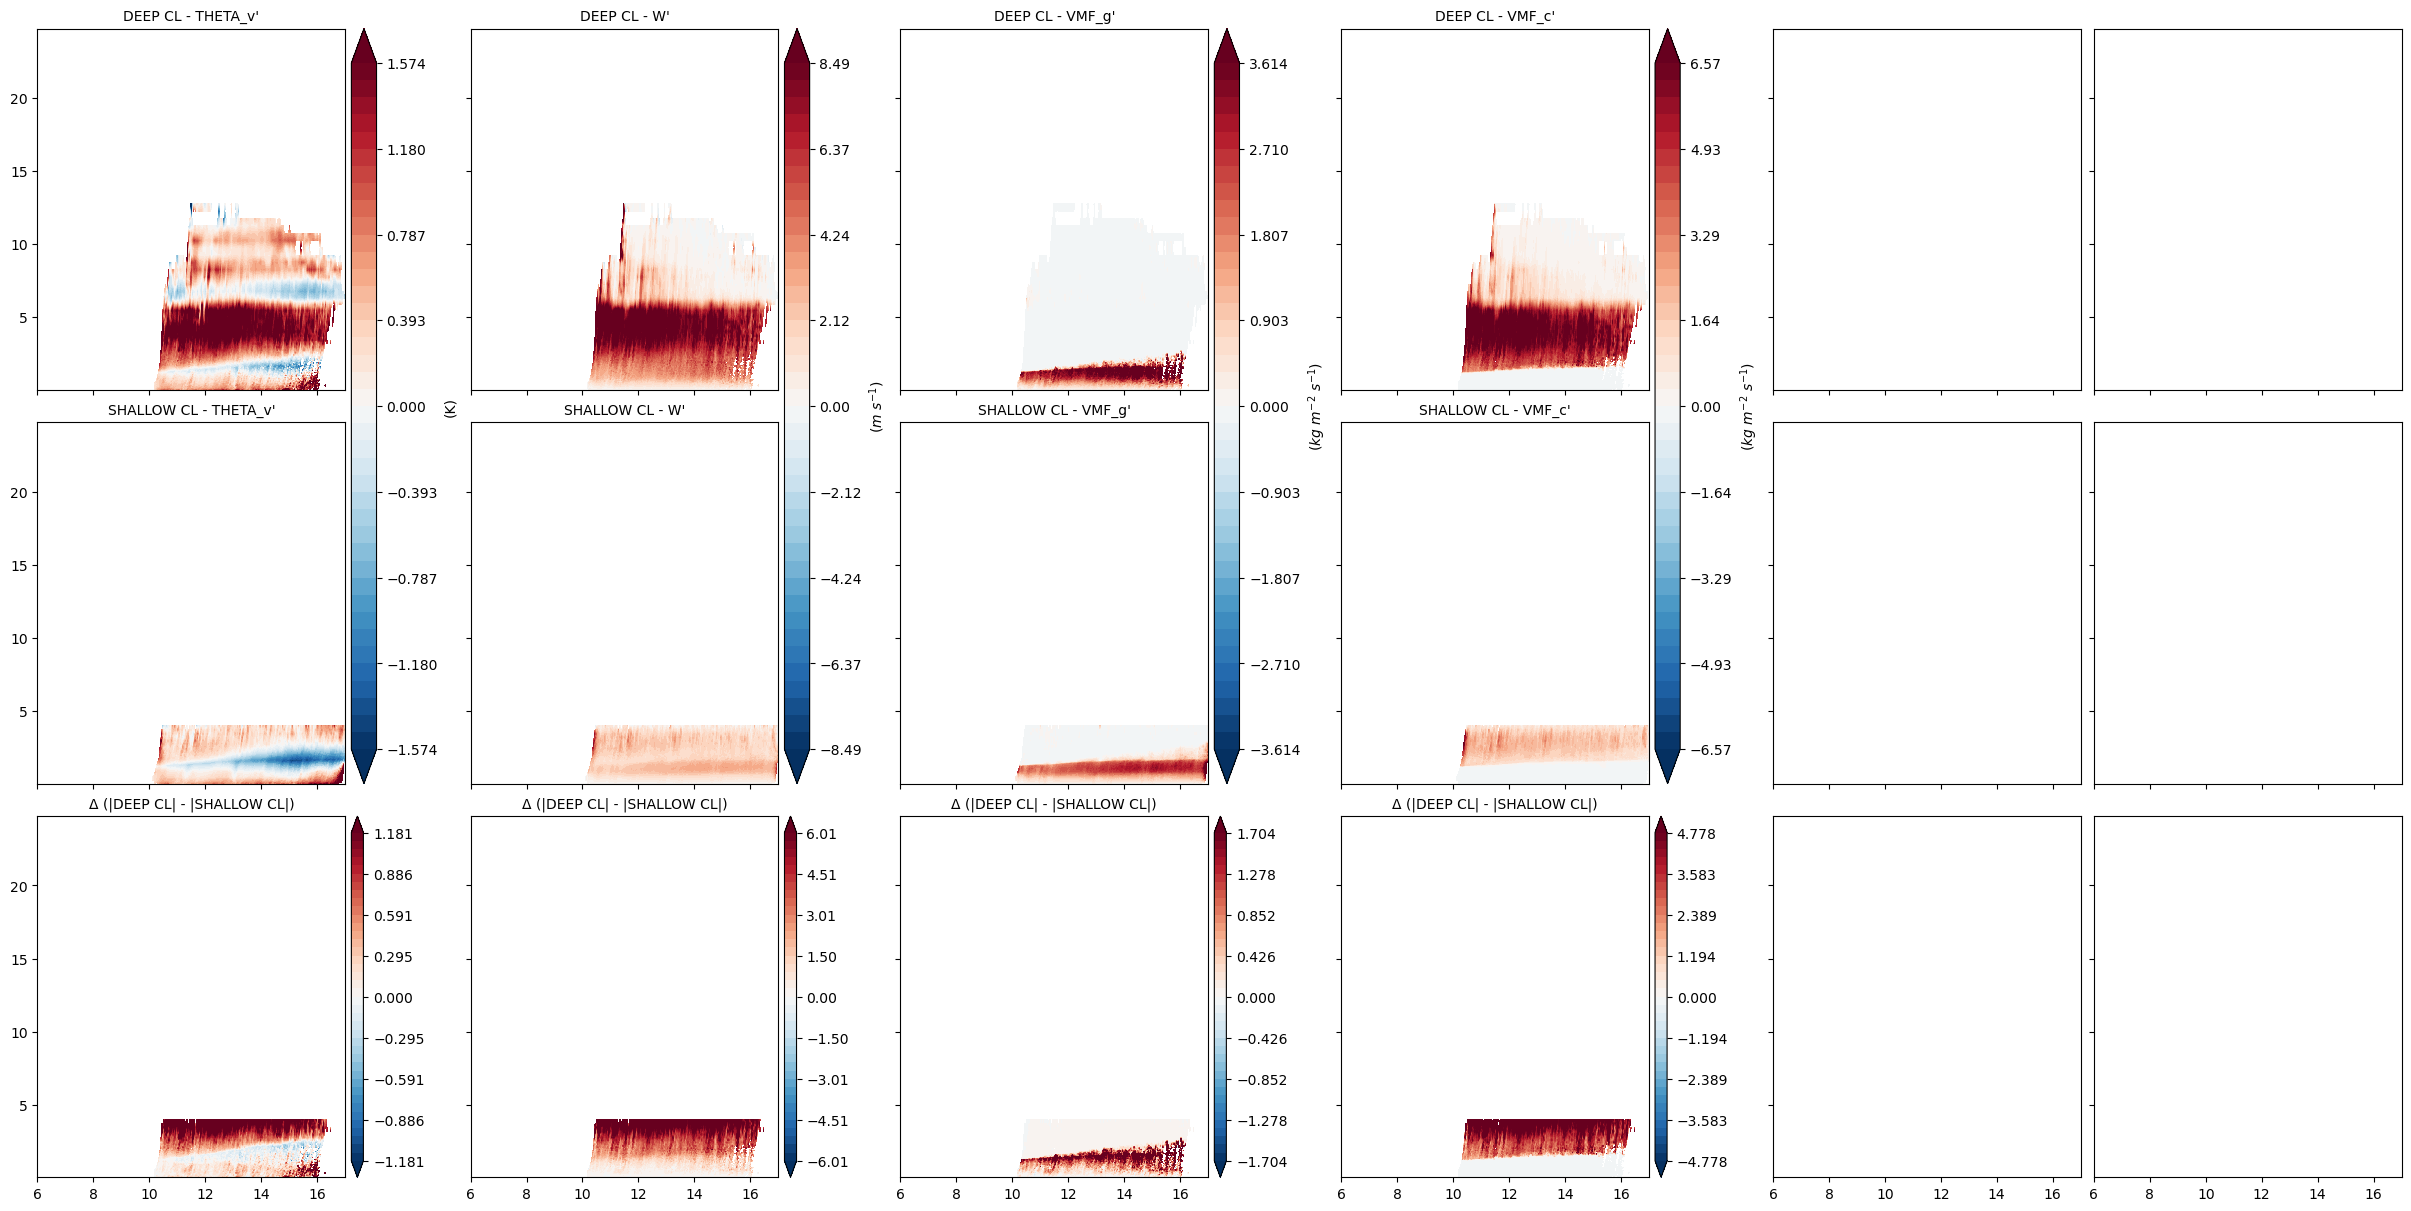

In [327]:
#plotting
parcelTypesList = [['CL','nonCL'],['CL','nonCL'], #cl vs noncl
                   ['CL','CL'],['nonCL','nonCL']]# #shallow vs deep
parcelDepthsList = [['SHALLOW','SHALLOW'],['DEEP','DEEP'], #cl vs noncl
                    ['DEEP','SHALLOW'], ['DEEP','SHALLOW']]# #shallow vs deep
if leftRightString == "left": parcelTypesList = [['CL','CL']]; parcelDepthsList = [['DEEP','SHALLOW']]
MakeTZContourMeanProfilePlots(parcelTypesList,parcelDepthsList,cmapDictionaryList,countThreshold=1)

In [ ]:
#plotting
parcelTypesList = [['ColdPool','nonCL'],['ColdPool','nonCL'], #coldpool vs noncl
                   ['ColdPool','ColdPool'],['nonCL','nonCL']]# #shallow vs deep
parcelDepthsList = [['SHALLOW','SHALLOW'],['DEEP','DEEP'], #coldpool vs noncl
                    ['DEEP','SHALLOW'], ['DEEP','SHALLOW']]# #shallow vs deep
if leftRightString == "left": parcelTypesList = [['ColdPool','ColdPool']]; parcelDepthsList = [['DEEP','SHALLOW']]
MakeTZContourMeanProfilePlots(parcelTypesList,parcelDepthsList,cmapDictionaryList,countThreshold=1)

In [ ]:
#########################################
#ALL VARIABLES MEAN PROFILE PLOTTING

In [ ]:
#Plotting Setup
if dataName=='Variables':
    varNames = ['QV', 'RH_vapor', 'HMC','QCQI',
                'THETA_e','THETA_v','THETA','BUOYANCY',
                'W', 'VMF_g', 'VMF_c']
    ncols=4
elif dataName=='UpdraftArea':
    varNames = ["UpdraftArea_g","UpdraftArea_c"]
    ncols=2

elif dataName=='Budgets':
    varNames = ["WB_BUOY","WB_PGRAD",
                "QVB_VADV","QVB_MP",
                "PTB_MP","PTB_VADV"]
    ncols=2
elif "Entrainment" in dataName:
    PROCESSED_string = "PROCESSED" if "PROCESSED" in dataName else ""
    DivideMassFlux_string = "_DivideMassFlux" if "DivideMassFlux" in dataName else ""
    varNames = [f"{PROCESSED_string}_NET{DivideMassFlux_string}_g",f"{PROCESSED_string}_NET{DivideMassFlux_string}_c"]
    ncols=2

t_hrs_List = [(10,17),(10,13),(13,17)]
parcelTypesList=[['CL','nonCL'],['ColdPool','nonCL']]

In [ ]:
PlotAllMeanProfiles_Combined(varNames,t_hrs_List,parcelTypesList,ncols=ncols,meanDataDictionary=None,countThreshold=1)
if dataName == 'Variables':
    PlotAllMeanProfiles_Combined(varNames,t_hrs_List,parcelTypesList,ncols=ncols,meanDataDictionary=meanDataDictionary_input,countThreshold=1)

In [ ]:
#########################################
#TESTING 

In [ ]:
# # #testing contours
# def SaveFigure(fig,plotType, folderName,fileName):
#     plotFileName = f"{fileName}_{ModelData.res}_{ModelData.t_res}_{ModelData.Np_str}.jpg"
#     plottingFileName = GetPlottingDirectory(plotFileName, plotType, folderName)
#     print(f"Saving figure to {plottingFileName}")
#     # fig.savefig(plottingFileName, dpi=300, bbox_inches='tight')
#     # plt.close(fig)

# #testing
# t_hrs_List = [(10,17)]
# parcelTypesList=[['CL','nonCL']]
# parcelDepthsList = [['SHALLOW','SHALLOW']]
# MakeTZContourMeanProfilePlots(parcelTypesList,parcelDepthsList,cmapDictionaryList,countThreshold=1)

In [ ]:
# #testing all variables mean profiles
# def SaveFigure(fig,plotType, folderName,fileName):
#     plotFileName = f"{fileName}_{ModelData.res}_{ModelData.t_res}_{ModelData.Np_str}.jpg"
#     plottingFileName = GetPlottingDirectory(plotFileName, plotType, folderName)
#     print(f"Saving figure to {plottingFileName}")
#     # fig.savefig(plottingFileName, dpi=300, bbox_inches='tight')
#     # plt.close(fig)

# PlotAllMeanProfiles_Combined(varNames,t_hrs_List,parcelTypesList,ncols=ncols,meanDataDictionary=None,countThreshold=1)
# if dataName == 'Variables':
#     PlotAllMeanProfiles_Combined(varNames,t_hrs_List,parcelTypesList,ncols=ncols,meanDataDictionary=meanDataDictionary_input,countThreshold=1)

In [ ]:
# #testing MeanProfile plots
# varName = 'QV'
# parcelTypes=['CL','nonCL']
# parcelDepths=['SHALLOW','SHALLOW']

# #testing difference at single times
# fig,axis=plt.subplots()
# t1_hrs=10;t2_hrs=13; [t1,t2] = GetTimeIndices(t1_hrs,t2_hrs)
# [cl_mean,noncl_mean] = MeanProfiles_MakeCalculations(ProfileArraysDictionary_2D,varName,parcelTypes,parcelDepths,t1,t2)
# MeanProfiles_MakePlot_both(parcelDepths, cl_mean,noncl_mean,t1_hrs,t2_hrs,axis=axis)

# fig,axis=plt.subplots()
# t1_hrs=13;t2_hrs=17; [t1,t2] = GetTimeIndices(t1_hrs,t2_hrs)
# [cl_mean,noncl_mean] = MeanProfiles_MakeCalculations(ProfileArraysDictionary_2D,varName,parcelTypes,parcelDepths,t1,t2)
# MeanProfiles_MakePlot_both(parcelDepths, cl_mean,noncl_mean,t1_hrs,t2_hrs,axis=axis)

# #testing difference at multiple times
# time_windows = [(10, 12), (10, 13), (10, 14),(10, 15),(10, 16),(10, 17)]
# fig,axis=plt.subplots()
# MeanProfile_PlotMultipleDifferencePlots(varName, parcelTypes,parcelDepths,time_windows,axis=axis)

# time_windows = [(16, 17), (15, 17), (14, 17), (13, 17), (12, 17)]
# fig,axis=plt.subplots()
# MeanProfile_PlotMultipleDifferencePlots(varName, parcelTypes,parcelDepths,time_windows,axis=axis)

# time_windows = [(10, 11), (11, 12), (12, 13), (13, 14), (14, 15), (15, 16), (16, 17)]
# fig,axis=plt.subplots()
# MeanProfile_PlotMultipleDifferencePlots(varName, parcelTypes,parcelDepths,time_windows,axis=axis)

In [ ]:
# #testing comparing average methods

# varName = 'QV'
# parcelTypes=['CL','nonCL']
# parcelDepths=['SHALLOW','SHALLOW']



# axis = plt.gca()
# nLevels=40
# plotType='pcolormesh'

# # --- load both ---
# profile1 = ProfileArraysDictionary_2D[parcelTypes[0]][parcelDepths[0]][varName][f'profile_array_{leftRightString}'].copy()
# count1   = ProfileArraysDictionary_2D[parcelTypes[0]][parcelDepths[0]][varName][f'profile_array_{leftRightString}_count'].copy()

# profile2 = ProfileArraysDictionary_2D[parcelTypes[1]][parcelDepths[1]][varName][f'profile_array_{leftRightString}'].copy()
# count2   = ProfileArraysDictionary_2D[parcelTypes[1]][parcelDepths[1]][varName][f'profile_array_{leftRightString}_count'].copy()

# mean1 = NanDivide(profile1, count1)
# mean2 = NanDivide(profile2, count2)

# # #perturbations calculated here
# # if meanDataDictionary is not None:
# #     mean1 -= meanDataDictionary[varKeyMatchDictionary[varName]]
# #     mean2 -= meanDataDictionary[varKeyMatchDictionary[varName]]

# if varName == "QCQI":
#     mean1 = np.where(mean1 <= 1e-6, np.nan, mean1)
#     mean2 = np.where(mean2 <= 1e-6, np.nan, mean2)

# times = np.arange(Nt) * ModelData.dt / 3600 + 6
# z = ModelData.zh

# multiplier = variableInfo[varName.rstrip("'")]["multiplier"]

# data1 = multiplier * mean1.T
# data2 = multiplier * mean2.T

# # difference
# dataDiff = NanSubtract(data1, data2)

# # --- symmetric limits around 0 ---
# vmax = np.nanpercentile(np.abs(dataDiff), 95)
# vmin = -vmax

# nLevels = nLevels if nLevels % 2 == 1 else nLevels + 1
# levels = np.linspace(vmin, vmax, nLevels)

# if plotType == 'contour':
#     plot = axis.contourf(times, z, dataDiff,
#                          cmap='RdBu_r', levels=levels, extend='both')
# else:
#     norm = mcolors.BoundaryNorm(levels, ncolors=plt.cm.RdBu_r.N, extend='both')
#     plot = axis.pcolormesh(times, z, dataDiff,
#                            cmap='RdBu_r', norm=norm, shading='auto')

# axis.set_ylim(0,6)
# axis.set_ylabel('z (km)')
# axis.set_xlabel('time (hrs)')
# fig.colorbar(plot,ax=axis,label=r'$\Delta\ q_v$')


# #testing comparing MeanProfile difference to mean of different contour

# # Create a 2x2 grid
# fig, axes = plt.subplots(2, 2, figsize=(10, 10), sharey=True)
# a=NanDivide(np.nansum(profile1,axis=0),np.nansum(count1,axis=0))
# b=NanDivide(np.nansum(profile2,axis=0),np.nansum(count2,axis=0))
# c=NanSubtract(a,b)
# if "Q" in varName: a*=multiplier;b*=multiplier;c*=multiplier
# means = [a,b,c,
#          np.nanmean(data1, 1), np.nanmean(data2, 1), np.nanmean(dataDiff, 1)]

# # ROW 1: Data from your direct calculations
# axes[0, 0].plot(means[0], ModelData.zh, 'g-', label='Data 1')
# axes[0, 0].plot(means[1], ModelData.zh, 'g--', label='Data 2')
# axes[0, 1].plot(means[2], ModelData.zh, 'k')

# # ROW 2: Data from variables a, b, c
# axes[1, 0].plot(means[3], ModelData.zh, 'g-', label='a')
# axes[1, 0].plot(means[4], ModelData.zh, 'g--', label='b')
# axes[1, 1].plot(means[5], ModelData.zh, 'k')
# axes[1, 1].set_ylabel('z (km)')

# # Formatting labels and helper lines
# row_titles = ['Individual Means\n[ (sum of data) / (sum of count) ]', 'Individual Means\n[ mean(data/count) ]']
# for i in range(2):
#     # --- Column 0 Logic ---
#     axes[i, 0].set_xlabel('qv')
#     axes[i, 0].set_ylabel('z (km)')
#     # Only the first column needs a "Row Title" usually
#     axes[i, 0].set_title(row_titles[i])
    
#     # --- Column 1 Logic ---
#     axes[i, 1].set_xlabel(r'$\Delta\ q_v$')
#     axes[i, 1].axvline(0, color='gray', lw=1, zorder=-30)
#     axes[i, 1].set_title(f'Difference')

# for axis in axes.flatten():
#     axis.set_ylim(0,6)
# plt.tight_layout()

In [ ]:
# #testing comparing average methods

# a=ProfileArraysDictionary_2D['CL']['SHALLOW']['QV'][f'profile_array_{leftRightString}_count'].copy()
# b=ProfileArraysDictionary_2D['nonCL']['SHALLOW']['QV'][f'profile_array_{leftRightString}_count'].copy()
# countThreshold=50
# a[a<=countThreshold]=np.nan
# b[b<=countThreshold]=np.nan

# time_hrs = np.arange(ModelData.Ntime)*ModelData.dt/3600+6

# import matplotlib.colors as colors
# import matplotlib.pyplot as plt

# # Create 2 rows, 1 column; sharex=True keeps the time labels clean
# fig, axes = plt.subplots(2, 1, sharex=True, figsize=(8, 10))
# data_list = [a, b]
# titles = ['Profile A', 'Profile B']

# for ax, data, title in zip(axes, data_list, titles):
#     pcm = ax.pcolormesh(time_hrs, ModelData.zh, data.T, 
#                         norm=colors.LogNorm(vmin=countThreshold, vmax=np.nanmax(data)),
#                         shading='auto')
#     plt.colorbar(pcm, ax=ax, label='Count')
#     ax.set_ylim(0, 6)
#     ax.set_ylabel('Height (km)')
#     ax.set_title(title)

# axes[-1].set_xlabel('Time (hrs)')
# plt.tight_layout()
# plt.show()